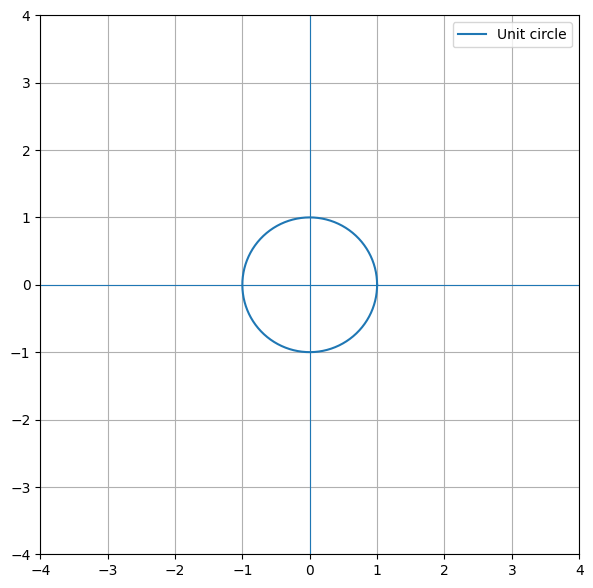

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a 2x2 matrix
A = np.array([
    [1.0, .7],
    [0.3, 1.5]
])

# Unit circle
theta = np.linspace(0, 2 * np.pi, 500)

circle = np.vstack([
    np.cos(theta),
    np.sin(theta)
])

# Transform every point on the circle
ellipse = A @ circle

def left_singular_pairs(M):
    """Singular values and the matching left singular vectors."""
    u, values, _ = np.linalg.svd(M)
    return [(float(value), vector) for value, vector in zip(values, u.T)]

def draw_arrows(pairs, color, legend_label, length_of):
    plt.plot([], [], color=color, lw=2, label=legend_label)
    for value, vector in pairs:
        tip = vector * length_of(value)
        plt.annotate(
            "",
            xy=tip,
            xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=2, mutation_scale=16),
        )
        plt.text(tip[0] * 1.08, tip[1] * 1.08, f"{value:.2f}", color=color, fontsize=9)

def style_axes():
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.gca().set_aspect("equal")
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)
    plt.grid()
    plt.legend()
    plt.show()

plt.figure(figsize=(7, 7))
plt.plot(circle[0], circle[1], label="Unit circle")
style_axes()

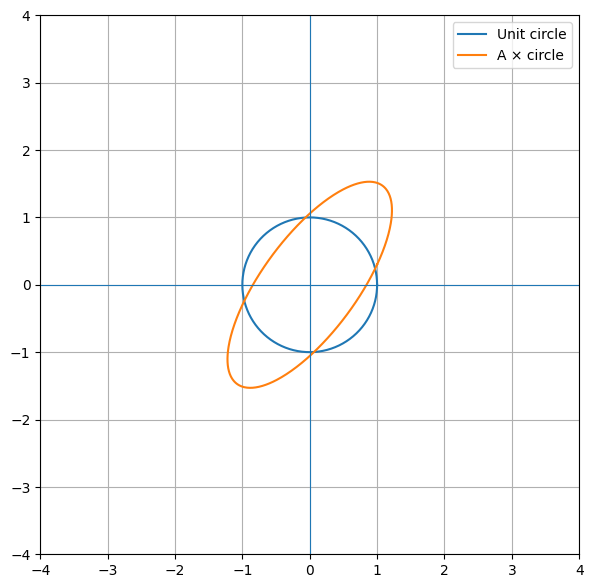

In [2]:
plt.figure(figsize=(7, 7))
plt.plot(circle[0], circle[1], label="Unit circle")
plt.plot(ellipse[0], ellipse[1], label="A × circle")
style_axes()

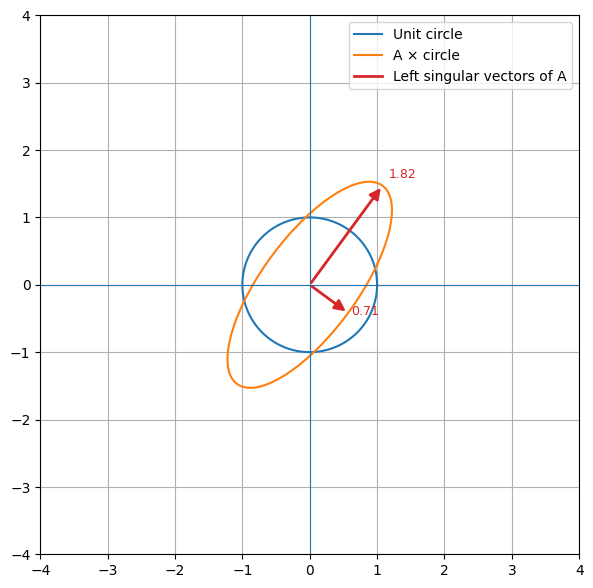

In [3]:
plt.figure(figsize=(7, 7))
plt.plot(circle[0], circle[1], label="Unit circle")
plt.plot(ellipse[0], ellipse[1], label="A × circle")
draw_arrows(
    left_singular_pairs(A),
    color="tab:red",
    legend_label="Left singular vectors of A",
    length_of=abs,
)
style_axes()